# 🧹 SQL Formatter & Linter - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/sql-formatter/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/sql-formatter/demo.ipynb)

> *"Our SQL is unreadable spaghetti."*

Two jobs: **format** SQL into a consistent house style, and **lint** it for safety
and style problems a formatter won't catch - `SELECT *`, a `DELETE` with no `WHERE`,
implicit joins. Formatting uses the battle-tested `sqlparse`; the lint rules are ours.

**What we cover**
1. Format ugly SQL
2. Lint for danger (the scary ones)
3. Lint for style
4. One-call analyze (format + lint)
5. Visualize issues by severity


## Step 1 - Format ugly SQL

One-liner in → readable, clause-per-line, keywords upper-cased.


In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from typing import Dict, List
import sqlparse

def format_sql(sql: str, *, keyword_case="upper", indent_width=2, reindent=True) -> str:
    if not sql or not sql.strip():
        return ""
    return sqlparse.format(sql, keyword_case=keyword_case, identifier_case=None,
                           reindent=reindent, indent_width=indent_width,
                           strip_comments=False, use_space_around_operators=True).strip()

ugly = "select id,name,email from users where status='active' and created_at>'2026-01-01'"
print(format_sql(ugly))

SELECT id,
       name,
       email
FROM users
WHERE status = 'active'
  AND created_at > '2026-01-01'


## Step 2 - Lint for danger

A formatter makes bad SQL *pretty*; it won't stop you dropping a table. These rules
catch the genuinely dangerous patterns.


In [2]:
@dataclass
class LintIssue:
    rule: str; severity: str; message: str

def _has(sql_upper, clause):
    return re.search(rf"\b{clause}\b", sql_upper) is not None

def lint_sql(sql: str) -> List[LintIssue]:
    issues = []
    if not sql or not sql.strip():
        return issues
    flat = re.sub(r"\s+", " ", sql).strip(); upper = flat.upper()
    if re.search(r"\bSELECT\s+\*", upper):
        issues.append(LintIssue("select_star","warning","Avoid SELECT * - list columns explicitly."))
    if _has(upper,"DELETE") and not _has(upper,"WHERE"):
        issues.append(LintIssue("delete_no_where","error","DELETE without WHERE affects every row."))
    if _has(upper,"UPDATE") and not _has(upper,"WHERE"):
        issues.append(LintIssue("update_no_where","error","UPDATE without WHERE changes every row."))
    if re.search(r"\bFROM\b[^;]*,[^;]*\bWHERE\b", upper):
        issues.append(LintIssue("implicit_join","style","Comma-style join - prefer explicit JOIN ... ON."))
    if not flat.endswith(";"):
        issues.append(LintIssue("no_semicolon","style","Not terminated with a semicolon."))
    if any(l != l.rstrip() for l in sql.splitlines()):
        issues.append(LintIssue("trailing_whitespace","style","Trailing whitespace on a line."))
    return issues

for i in lint_sql("DELETE FROM users"):
    print(f"[{i.severity}] {i.rule}: {i.message}")

[error] delete_no_where: DELETE without WHERE affects every row.
[style] no_semicolon: Not terminated with a semicolon.


## Step 3 - Lint for style

Less scary, still worth fixing - `SELECT *`, comma joins, missing semicolons.


In [3]:
sample = "SELECT * FROM orders o, customers c WHERE o.customer_id = c.id"
for i in lint_sql(sample):
    print(f"[{i.severity}] {i.rule}: {i.message}")

[warning] select_star: Avoid SELECT * - list columns explicitly.
[style] implicit_join: Comma-style join - prefer explicit JOIN ... ON.
[style] no_semicolon: Not terminated with a semicolon.


## Step 4 - One call: format + lint

The shape the API and UI both consume.


In [4]:
def analyze(sql, **opts):
    issues = lint_sql(sql)
    return {"formatted": format_sql(sql, **opts),
            "issues": [i.__dict__ for i in issues],
            "issue_count": len(issues),
            "error_count": sum(1 for i in issues if i.severity == "error")}

queries = {
    "clean":     "SELECT id, name FROM users WHERE active = true;",
    "select_star":"select * from orders",
    "danger":    "delete from sessions",
    "messy_join":"select a.id,b.name from a,b where a.id=b.id",
}
results = {name: analyze(q) for name, q in queries.items()}
for name, r in results.items():
    print(f"{name:12s} issues={r['issue_count']} errors={r['error_count']}")

clean        issues=0 errors=0
select_star  issues=2 errors=0
danger       issues=2 errors=1
messy_join   issues=2 errors=0


## Step 5 - Issues by severity, visualized

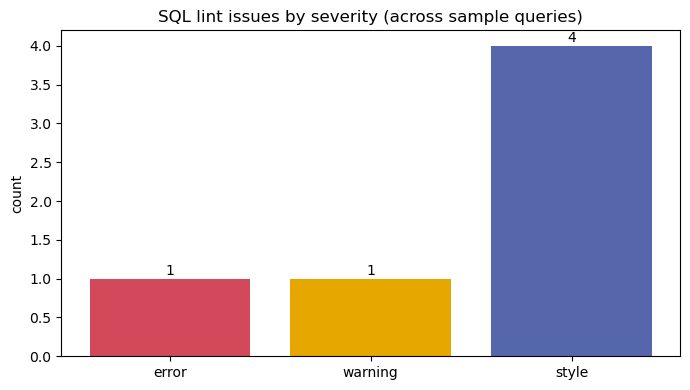

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

sev = Counter()
for r in results.values():
    for i in r["issues"]:
        sev[i["severity"]] += 1

order = ["error", "warning", "style"]
colors = {"error":"#d1495b","warning":"#e6a700","style":"#5566aa"}
vals = [sev.get(s, 0) for s in order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(order, vals, color=[colors[s] for s in order])
for i, v in enumerate(vals):
    ax.text(i, v + 0.05, str(v), ha="center")
ax.set_ylabel("count"); ax.set_title("SQL lint issues by severity (across sample queries)")
plt.tight_layout(); plt.savefig("lint.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- **Format** with `sqlparse` → consistent house style (keyword case, clause-per-line).
- **Lint** with our own rules → catches danger (`DELETE`/`UPDATE` with no `WHERE`),
  performance (`SELECT *`), and style (implicit joins, missing semicolons).
- `analyze` returns both in one call - the contract behind the FastAPI service.

Reusable as a governed **SQL tools** app on the platform shell.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run the microservice:**
```bash
pip install -r requirements.txt
uvicorn api:app --reload
# open http://localhost:8000  (test form)  or  /docs
```
